# Week 1 ECG Visualization

Notebook recovered with a minimal valid structure.

# This notebook will contain:

Load ECG data from MIT-BIH dataset

Inspect the signal

Plot the ECG waveform

Show heartbeat annotations

The 3 Important File Types

Every record has 3 files.

1.dat file/n

This file contains the actual ECG signal numbers.

2️.hea file (Header)

This file contains metadata about the recording.
Example:

100 2 360 650000
| Value  | Meaning            |
| ------ | ------------------ |
| 100    | record number      |
| 2      | number of leads    |
| 360    | samples per second |
| 650000 | total samples      |

3.atr file (Annotations)

This file contains labels for heartbeats.

Doctors manually annotated these beats.

Example conceptually:
sample_index   beat_type
77             N
370            N
662            V
946            N

| Symbol | Meaning          |
| ------ | ---------------- |
| N      | Normal beat      |
| V      | Ventricular beat |
| A      | Atrial beat      |
| L      | Left bundle beat |

These annotations are very important because they are the ground truth labels for ML.


In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/mitdb/"
RECORD_NAME = "100"

In [3]:
record = wfdb.rdrecord(DATA_PATH + RECORD_NAME)
annotation = wfdb.rdann(DATA_PATH + RECORD_NAME, "atr")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)

Signal shape: (650000, 2)
Sampling frequency: 360


650000 samples ÷ 360 samples/sec
≈ 1805 seconds
≈ 30 minutes

| Term           | Meaning                          |
| -------------- | -------------------------------- |
| 650000 samples | total ECG measurements           |
| 2 leads        | two different heart signal views |
| 360 Hz         | 360 measurements per second      |
| 30 minutes     | total recording length           |


In [6]:
#Inspect Signal Data
record.p_signal[:10]

array([[-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.145, -0.065],
       [-0.12 , -0.08 ],
       [-0.135, -0.08 ]])

Each row = ECG voltage reading

Plot First 1000 Samples

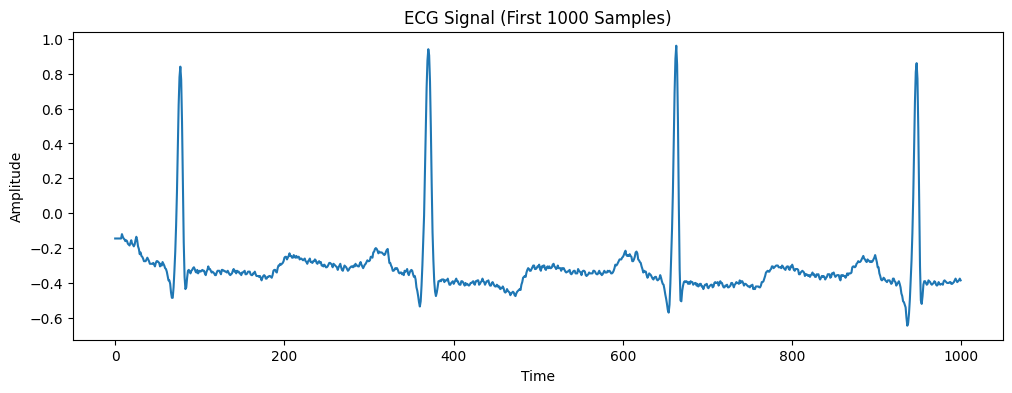

In [10]:
plt.figure(figsize=(12,4))

plt.plot(record.p_signal[:1000,0])

plt.title("ECG Signal (First 1000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

Plot Longer ECG Segment

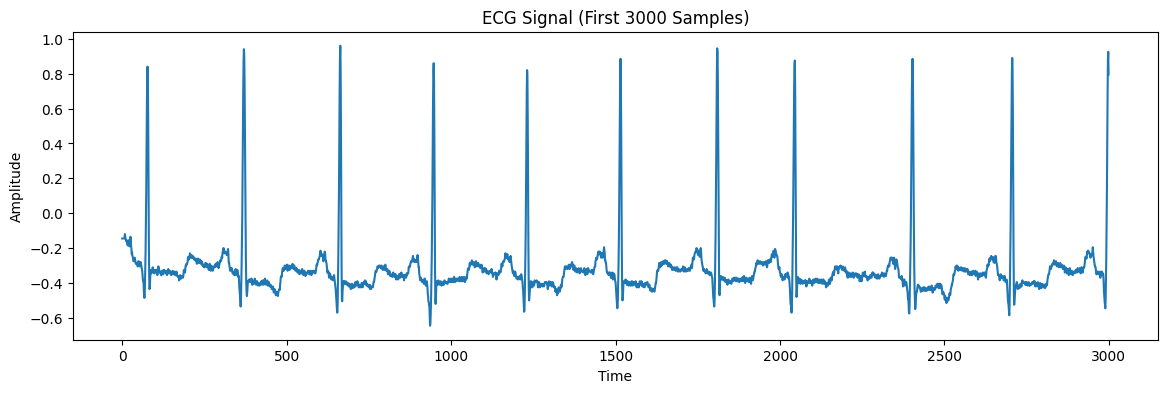

In [11]:
plt.figure(figsize=(14,4))

plt.plot(record.p_signal[:3000,0])
# means:
# Take first 3000 samples
# from lead 0
#3000 / 360 ≈ 8.33 seconds
plt.title("ECG Signal (First 3000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

View Annotation Information

Annotations tell us what type of heartbeat occurred.

In [12]:
print("First 10 annotation samples:")
print(annotation.sample[:10])

print("First 10 annotation symbols:")
print(annotation.symbol[:10])

First 10 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


| Sample | Time     |
| ------ | -------- |
| 77     | 0.21 sec |
| 370    | 1.02 sec |
| 662    | 1.84 sec |
| 946    | 2.63 sec |

So the heartbeats occurred at those time points.

Plot ECG with Beat Markers

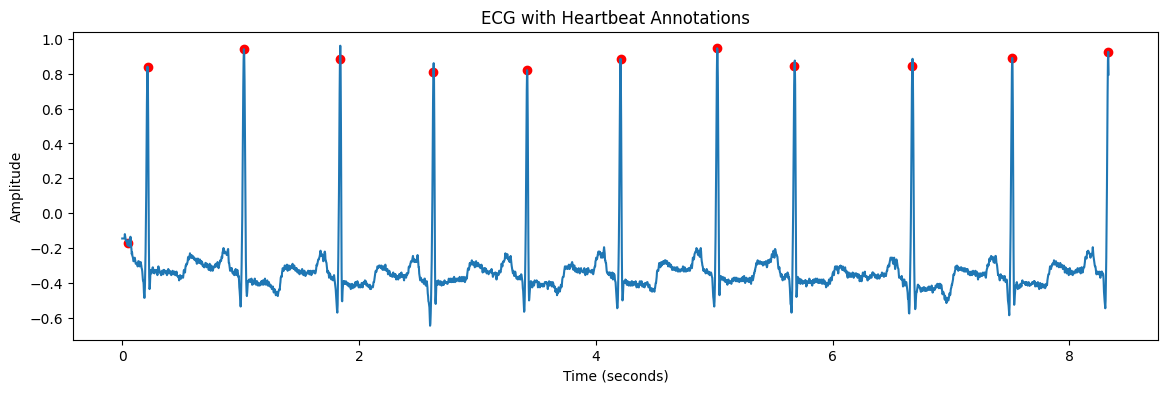

In [14]:
plt.figure(figsize=(14,4))

signal = record.p_signal[:3000,0]

# convert samples to time
time = np.arange(len(signal)) / record.fs

plt.plot(time, signal)

beat_positions = annotation.sample
beat_positions = beat_positions[beat_positions < 3000]

plt.scatter(beat_positions/record.fs, signal[beat_positions], color='red')

plt.title("ECG with Heartbeat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

Basic Statistics

In [15]:
print("Min value:", np.min(record.p_signal))
print("Max value:", np.max(record.p_signal))
print("Mean value:", np.mean(record.p_signal))

Min value: -2.715
Max value: 1.435
Mean value: -0.24866670384615383


Why This Is Useful

These statistics help you understand:

Signal range

Noise level

Scaling needed for ML
